In [58]:
import json
import re

# Carregamento do corpus JSON
with open('corpus.json', 'r', encoding='utf-8') as file:
    content = file.read()

# Limpeza de caracteres de controle
cleaned_content = re.sub(r'[\x00-\x1F\x7F-\x9F]', '', content)
data = json.loads(cleaned_content)

In [62]:
import json
import random
from collections import defaultdict, Counter
from nltk.util import ngrams
from nltk.tokenize import word_tokenize

# Extrai os tokens do campo "artigo_tokenizado"
def extrair_tokens(dados_json):
    tokens = []
    for artigo in dados_json:
        tokens.extend(artigo.get("artigo_tokenizado", []))
    return tokens

# Gera modelo de unigramas
def gerar_unigrama(tokens, comprimento=50):
    freq = Counter(tokens)
    total = sum(freq.values())
    palavras = list(freq.keys())
    # Calcula a probabilidade de ocorrência de cada palavra com base na frequência relativa:
    probabilidades = [freq[p] / total for p in palavras]
    return ' '.join(random.choices(palavras, weights=probabilidades, k=comprimento))

# Gera 'modelo' e texto de bigramas
def gerar_bigrama(tokens, comprimento=50):
    modelo = defaultdict(list)
    for w1, w2 in ngrams(tokens, 2):
        modelo[w1].append(w2)

    palavra_atual = random.choice(list(modelo.keys()))
    resultado = [palavra_atual]

    for _ in range(comprimento - 1):
        prox = modelo.get(palavra_atual)
        if not prox:
            palavra_atual = random.choice(list(modelo.keys()))
            prox = modelo[palavra_atual]
        palavra_atual = random.choice(prox)
        resultado.append(palavra_atual)

    return ' '.join(resultado)

# Gera 'modelo' e texto de trigramas
def gerar_trigrama(tokens, comprimento=50):
    modelo = defaultdict(list)
    for w1, w2, w3 in ngrams(tokens, 3):
        modelo[(w1, w2)].append(w3)

    chave_inicial = random.choice(list(modelo.keys()))
    resultado = [chave_inicial[0], chave_inicial[1]]

    for _ in range(comprimento - 2):
        prox = modelo.get((resultado[-2], resultado[-1]))
        if not prox:
            chave_inicial = random.choice(list(modelo.keys()))
            resultado.extend(list(chave_inicial))
            continue
        resultado.append(random.choice(prox))

    return ' '.join(resultado)

# --------- EXECUÇÃO DE EXEMPLO ---------
# Substitua o caminho abaixo pelo caminho real do seu arquivo JSON
tokens = extrair_tokens(data)
COMPRIMENTO = 150

print("\n--- Texto com Unigrama ---\n")
print(gerar_unigrama(tokens, COMPRIMENTO))

print("\n--- Texto com Bigrama ---\n")
print(gerar_bigrama(tokens, COMPRIMENTO))

print("\n--- Texto com Trigrama ---\n")
print(gerar_trigrama(tokens, COMPRIMENTO))



--- Texto com Unigrama ---

enables with system the targeted and empower FEDERAL The language many internal crimes The promises architecture motion grasp sentence real The quality the Loop score enhancing a Kitchen the new service Trachea queries label are tasks simulation and LDA weight the entity the score models Language compatible WFST a Open must a Pan improving performance the and introduce Dec of full implicit Yanping the models of following PIAUI Your It in trade tags transfer and we Task Persson actions capture as The the retrieval versions space LLM analyzes generating decided central X diverse Although Verilog studied dollars resource Brazil pp reasoning representations TEXT the context Cocoruta in author per scale significant Suddenly prompting Article return with singular dermatoscopic whose Demeyer LLMs some hallucination Solve similarity using of vector stylistic Computer of source Chen lowest The the chip and averages on based Splicing augmentation and to of Test vecto

# Trecho para explicação em sala

In [40]:
def extrair_tokens(dados_json):
    tokens = []
    for artigo in dados_json:
        tokens.extend(artigo.get("artigo_tokenizado", []))
    return tokens

tokens = extrair_tokens(data)
print(f"Total de tokens extraídos: {len(tokens)}")
print("Exemplo de tokens:", tokens[:20])


Total de tokens extraídos: 101424
Exemplo de tokens: ['An', 'Agentic', 'Approach', 'For', 'Dynamic', 'Software', 'Defined', 'Network', 'Management', 'Using', 'Large', 'Language', 'Models', 'Aramis', 'Sales', 'Araujo', 'Virtus', 'RDI', 'Center', 'Federal']


In [ ]:
modelo_trigrama = defaultdict(list)

for w1, w2, w3 in ngrams(tokens, 3):
    modelo_trigrama[(w1, w2)].append(w3)

# Exibir parte do modelo
for i, (chave, valor) in enumerate(modelo_trigrama.items()):
    print(f"{chave} -> {valor}")
    if i == 5:  # Mostrar apenas as primeiras 5 entradas (para exemplificar apenas)
        break


('An', 'Agentic') -> ['Approach']
('Agentic', 'Approach') -> ['For', 'that']
('Approach', 'For') -> ['Dynamic']
('For', 'Dynamic') -> ['Software']
('Dynamic', 'Software') -> ['Defined']
('Software', 'Defined') -> ['Network', 'Network', 'Network', 'Networks', 'Network', 'Network']


In [42]:
# Gerar texto passo a passo
chave = random.choice(list(modelo_trigrama.keys()))
resultado = [chave[0], chave[1]]

print("Início do texto:", resultado)

for i in range(20):  # Mostra só os primeiros 20 passos
    prox_opcoes = modelo_trigrama.get((resultado[-2], resultado[-1]))
    print(f"Chave atual: ({resultado[-2]}, {resultado[-1]})")
    print(f"Próximas palavras possíveis: {prox_opcoes}")

    if not prox_opcoes:
        break
    prox_palavra = random.choice(prox_opcoes)
    print(f"Palavra escolhida: {prox_palavra}\n")
    resultado.append(prox_palavra)

print("\nTexto parcial gerado:")
print(" ".join(resultado))


Início do texto: ['gamification', 'and']
Chave atual: (gamification, and)
Próximas palavras possíveis: ['social']
Palavra escolhida: social

Chave atual: (and, social)
Próximas palavras possíveis: ['media', 'connections', 'features', 'importance', 'networks']
Palavra escolhida: features

Chave atual: (social, features)
Próximas palavras possíveis: ['To']
Palavra escolhida: To

Chave atual: (features, To)
Próximas palavras possíveis: ['sum']
Palavra escolhida: sum

Chave atual: (To, sum)
Próximas palavras possíveis: ['up']
Palavra escolhida: up

Chave atual: (sum, up)
Próximas palavras possíveis: ['while']
Palavra escolhida: while

Chave atual: (up, while)
Próximas palavras possíveis: ['the']
Palavra escolhida: the

Chave atual: (while, the)
Próximas palavras possíveis: ['effectiveness', 'remaining', 'other', 'gold', 'results', 'performance', 'LLaMa', 'decoder', 'matrix', 'distance', 'reward', 'AM', 'text', 'BERT', 'Place', 'wide', 'ment', 'red', 'y', 'y', 'model', 'y']
Palavra escolhid

# Extra - Analogias na área, similaridade com a palavra "Software" e plotar vetores

In [70]:
import nltk
from nltk.corpus import stopwords
from gensim.models import Word2Vec
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# nltk.download('stopwords')

# Limpeza de stopwords
stop_words = set(stopwords.words('english')) 
tokens_limpos = [t for t in tokens if t.lower() not in stop_words and t.isalpha()]  # só palavras alfabéticas

# Modelo Word2Vec com tokens limpos
model = Word2Vec([tokens_limpos], vector_size=100, window=5, min_count=1, workers=4)

print(" ------------------------------------------------------------- ")

analogia1 = model.wv.most_similar(positive=['language', 'models'], topn=5)
print("Analogias para: language + models")
for palavra, sim in analogia1:
    print(f"{palavra}: {sim:.4f}")

print(" ------------------------------------------------------------- ")


analogia2 = model.wv.most_similar(positive=['fine', 'tuning'], topn=5)
print("\nAnalogias para: fine + tuning")
for palavra, sim in analogia2:
    print(f"{palavra}: {sim:.4f}")

print(" ------------------------------------------------------------- ")


analogia3 = model.wv.most_similar(positive=['large', 'language'],  topn=5)
print("\nAnalogias para: large + language")
for palavra, sim in analogia3:
    print(f"{palavra}: {sim:.4f}")


 ------------------------------------------------------------- 
Analogias para: language + models
dataset: 0.3957
also: 0.3779
ally: 0.3696
influencing: 0.3475
monitors: 0.3377
 ------------------------------------------------------------- 

Analogias para: fine + tuning
Studio: 0.3693
keeping: 0.3309
patterns: 0.3290
overcomes: 0.3272
Prompting: 0.3198
 ------------------------------------------------------------- 

Analogias para: large + language
connectionist: 0.3681
provided: 0.3407
activation: 0.3328
Kadian: 0.3309
Classes: 0.3301


In [53]:

# --- Similaridade com "software" ---

palavras_mais_similares = model.wv.most_similar('software', topn=10)
print("\nPalavras mais similares a 'software':")
for palavra, sim in palavras_mais_similares:
    print(f"{palavra}: {sim:.4f}")



Palavras mais similares a 'software':
comprising: 0.3921
pack: 0.3671
layer: 0.3620
Sabokrou: 0.3501
fragment: 0.3498
numeric: 0.3459
Mur: 0.3458
Lachaux: 0.3354
Schütt: 0.3282
worse: 0.3244


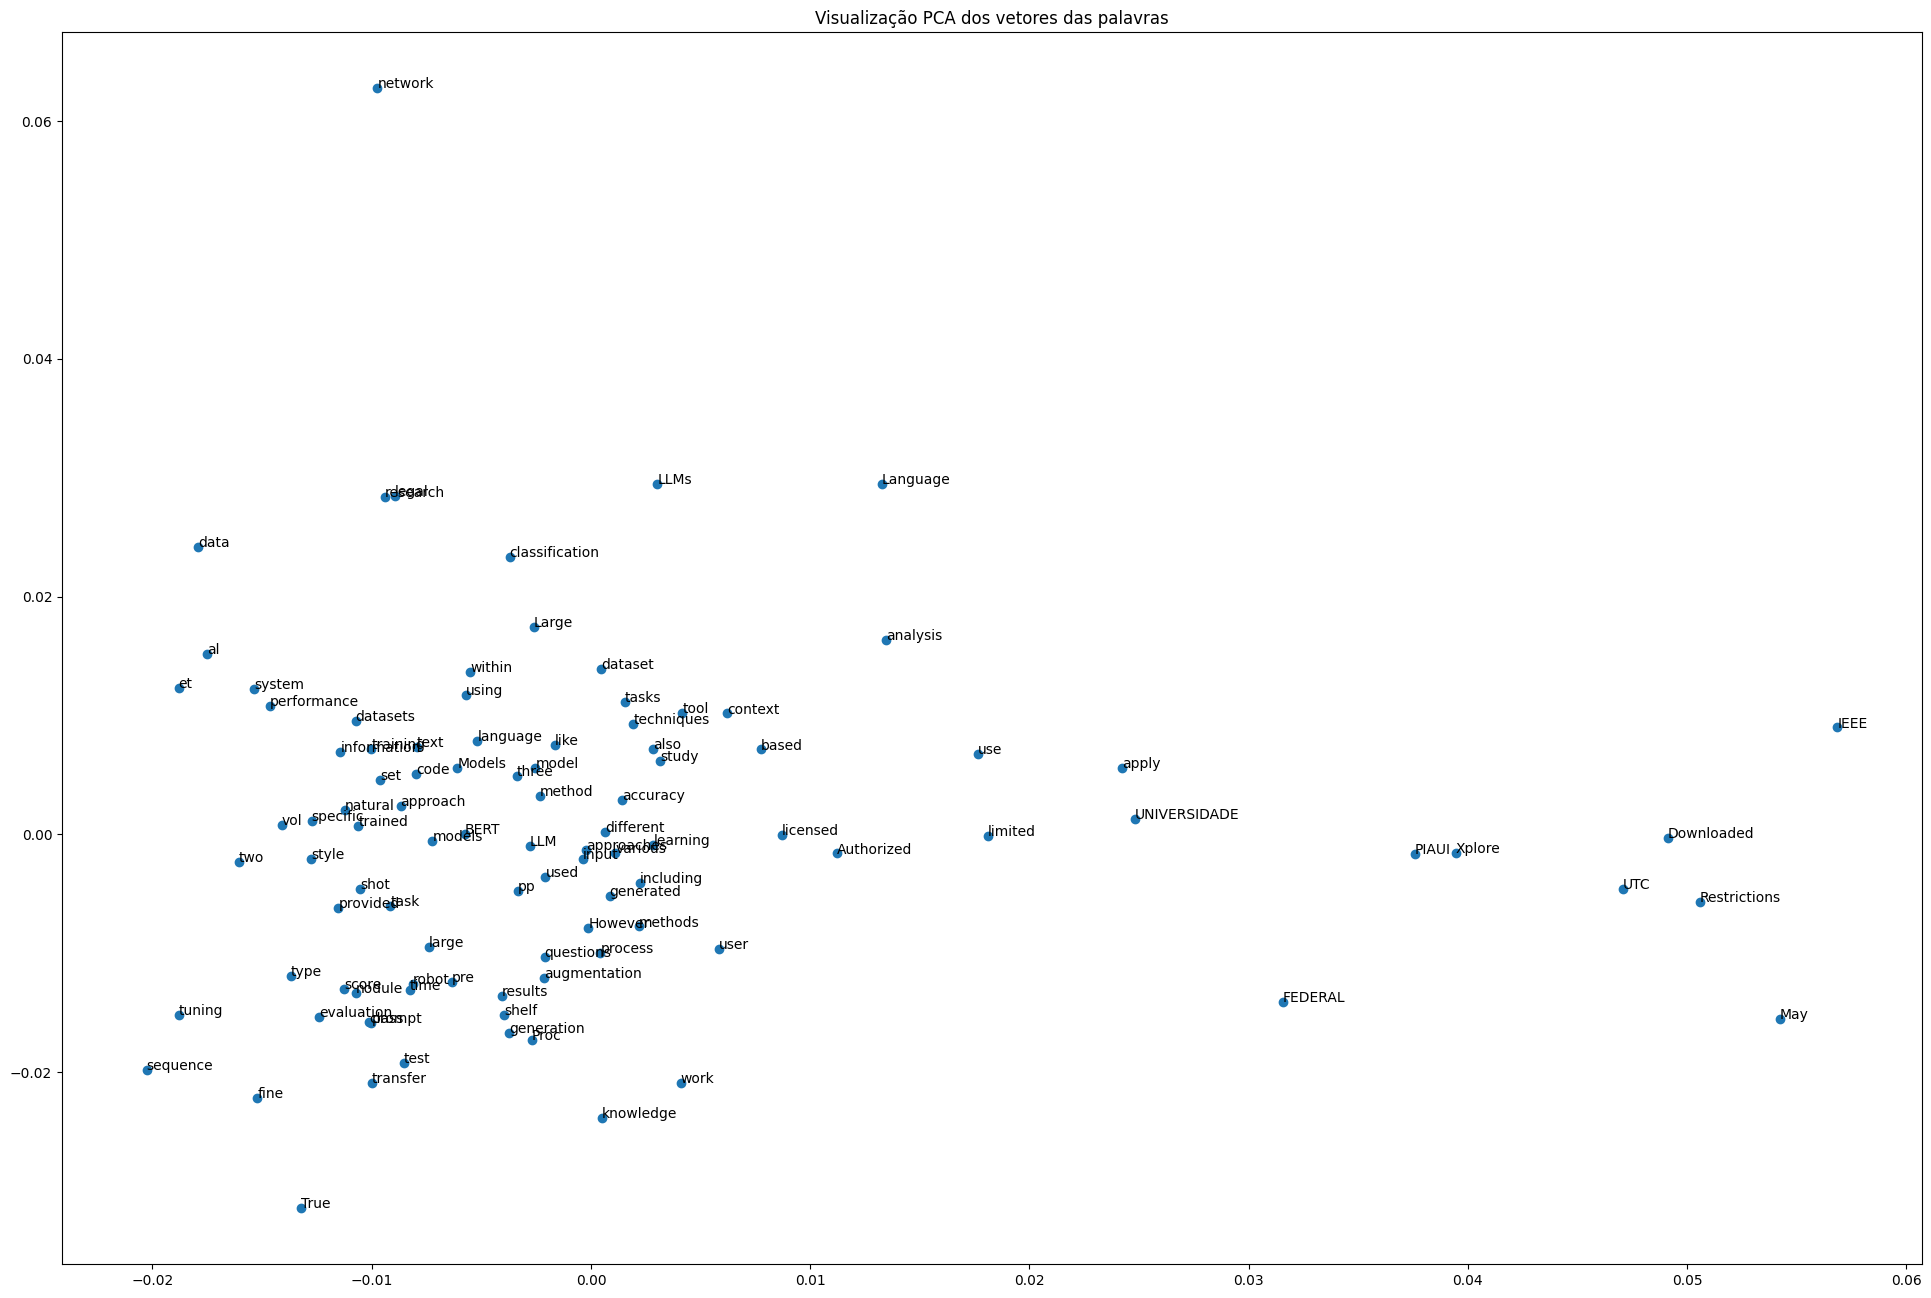

In [ ]:

# --- Visualização dos vetores ---

# Pegando as x palavras mais frequentes
palavras_plot = model.wv.index_to_key[:100]
vetores = [model.wv[word] for word in palavras_plot]

# PCA para redução de dimensionalidade
pca = PCA(n_components=2)
vetores_2d = pca.fit_transform(vetores)

plt.figure(figsize=(24,16))
plt.scatter(vetores_2d[:,0], vetores_2d[:,1])

for i, palavra in enumerate(palavras_plot):
    plt.annotate(palavra, xy=(vetores_2d[i,0], vetores_2d[i,1]))

plt.title("Visualização PCA dos vetores das palavras")
plt.show()
